In [25]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [26]:
# ------ PATH ----------
BASE_PATH = "training"

LEFT_DIR = os.path.join(BASE_PATH, "image_2")
RIGHT_DIR = os.path.join(BASE_PATH, "image_3")
GT_DIR = os.path.join(BASE_PATH, "disp_noc_0")

print("Left Images:", len(os.listdir(LEFT_DIR)))
print("Right Images:", len(os.listdir(RIGHT_DIR)))
print("Ground Truth:", len(os.listdir(GT_DIR)))

Left Images: 200
Right Images: 200
Ground Truth: 200


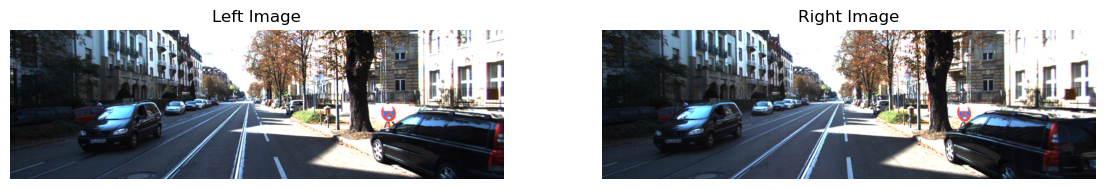

In [27]:
# ------ Load Kitti Stereo Pair ----------
def load_stereo_pair(index=0):
    left_files = sorted(os.listdir(LEFT_DIR))
    right_files = sorted(os.listdir(RIGHT_DIR))

    left_path = os.path.join(LEFT_DIR, left_files[index])
    right_path = os.path.join(RIGHT_DIR, right_files[index])

    left = cv2.cvtColor(cv2.imread(left_path), cv2.COLOR_BGR2RGB)
    right = cv2.cvtColor(cv2.imread(right_path), cv2.COLOR_BGR2RGB)

    return left, right

left_img, right_img = load_stereo_pair(0)

plt.figure(figsize=(14,5))
plt.subplot(1,2,1); plt.imshow(left_img); plt.title("Left Image"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(right_img); plt.title("Right Image"); plt.axis("off")
plt.show()

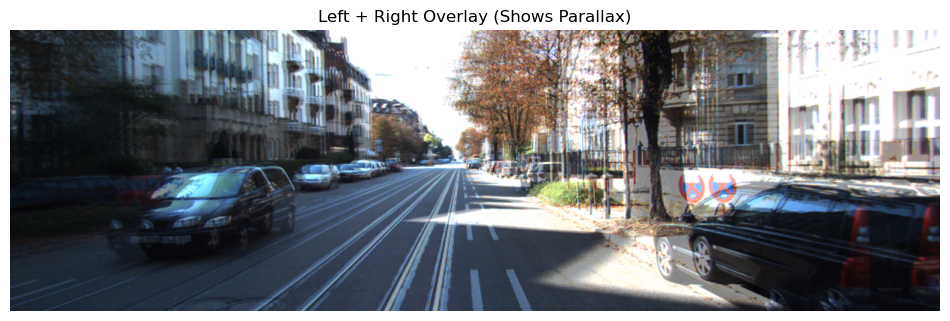

In [28]:
# ------ Showing difference between Left image and Right image ----------
overlay = cv2.addWeighted(left_img, 0.5, right_img, 0.5, 0)

plt.figure(figsize=(12,4))
plt.imshow(overlay)
plt.title("Left + Right Overlay (Shows Parallax)")
plt.axis("off")
plt.show()

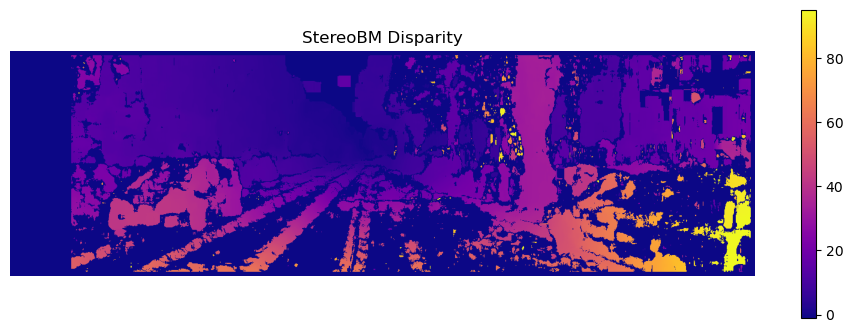

In [29]:
# ------ Classical Approach — StereoBM ----------
def disparity_bm(left, right, num_disparities=96, block_size=15):
    grayL = cv2.cvtColor(left, cv2.COLOR_RGB2GRAY)
    grayR = cv2.cvtColor(right, cv2.COLOR_RGB2GRAY)

    num_disparities = (num_disparities // 16) * 16
    stereo = cv2.StereoBM_create(numDisparities=num_disparities,
                                 blockSize=block_size)
    
    disp = stereo.compute(grayL, grayR).astype(np.float32) / 16.0
    return disp

disp_bm = disparity_bm(left_img, right_img)

plt.figure(figsize=(12,4))
plt.imshow(disp_bm, cmap='plasma')
plt.title("StereoBM Disparity"); plt.axis("off")
plt.colorbar(); plt.show()

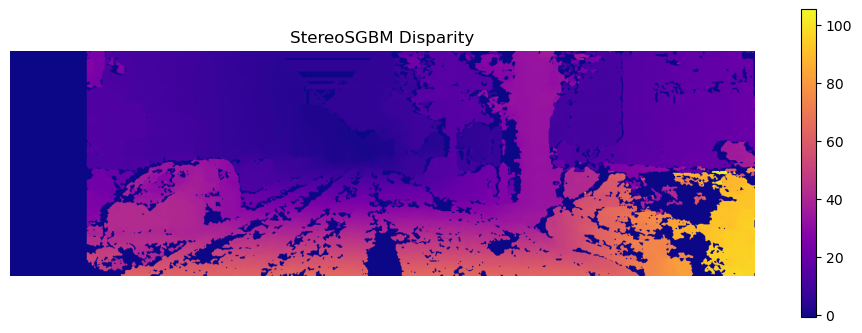

In [30]:
# ------ Classical Approach — StereoSGBM ----------
def disparity_sgbm(left, right):
    grayL = cv2.cvtColor(left, cv2.COLOR_RGB2GRAY)
    grayR = cv2.cvtColor(right, cv2.COLOR_RGB2GRAY)

    stereo = cv2.StereoSGBM_create(
        minDisparity=0,
        numDisparities=128,
        blockSize=5,
        P1=8 * 3 * 5**2,
        P2=32 * 3 * 5**2,
        uniquenessRatio=10,
        speckleWindowSize=100,
        speckleRange=32,
        disp12MaxDiff=1
    )

    disp = stereo.compute(grayL, grayR).astype(np.float32) / 16.0
    return disp

disp_sgbm = disparity_sgbm(left_img, right_img)

plt.figure(figsize=(12,4))
plt.imshow(disp_sgbm, cmap='plasma')
plt.title("StereoSGBM Disparity"); plt.axis("off")
plt.colorbar(); plt.show()

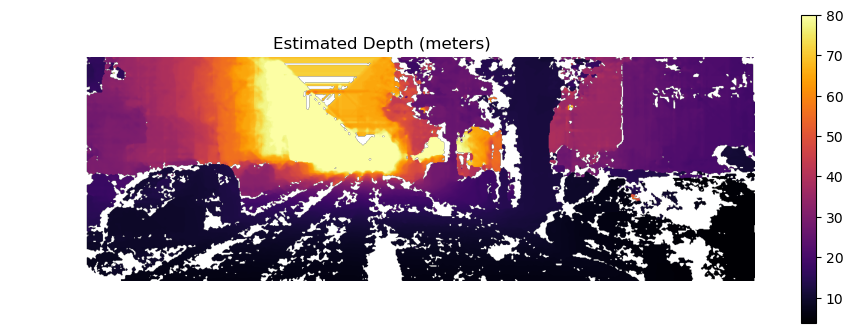

In [31]:
# ------ Convert Disparity → Depth (Z = f·B / d) ----------
FOCAL = 721.0
BASELINE = 0.54

def disparity_to_depth(disparity):
    disp = np.copy(disparity)
    disp[disp <= 0] = np.nan
    depth = (FOCAL * BASELINE) / disp
    return depth

depth_map = disparity_to_depth(disp_sgbm)

plt.figure(figsize=(12,4))
plt.imshow(np.clip(depth_map, 0, 80), cmap='inferno')
plt.title("Estimated Depth (meters)"); plt.axis("off")
plt.colorbar(); plt.show()

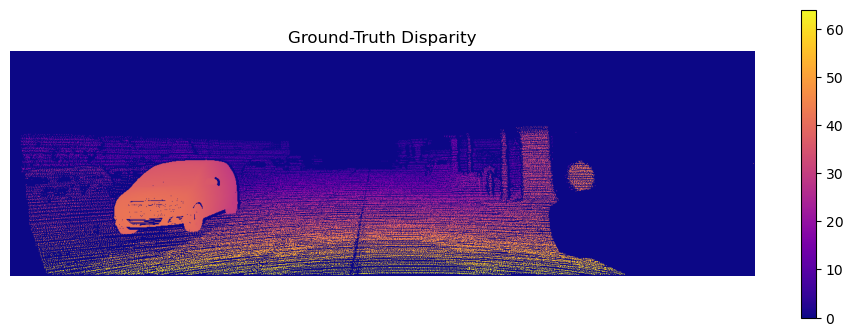

In [32]:
# ------ Load Ground Truth Disparity ----------
def load_gt(index=0):
    gt_files = sorted(os.listdir(GT_DIR))
    gt_path = os.path.join(GT_DIR, gt_files[index])
    gt = cv2.imread(gt_path, -1).astype(np.float32)
    gt = gt / 256.0
    return gt

gt = load_gt(0)

plt.figure(figsize=(12,4))
plt.imshow(gt, cmap='plasma')
plt.title("Ground-Truth Disparity"); plt.axis("off")
plt.colorbar(); plt.show()

In [33]:
# ------ StereoBM Evaluation Metrics (RMSE, MAE, Bad Pixels) ----------
def evaluate(pred, gt):
    mask = gt > 0
    pred = pred[mask]
    gt = gt[mask]

    rmse = np.sqrt(mean_squared_error(gt, pred))
    mae  = mean_absolute_error(gt, pred)
    bad  = np.mean(np.abs(pred - gt) > 3) * 100.0

    return rmse, mae, bad

rmse_bm, mae_bm, bad_bm = evaluate(disp_bm, gt)
print("===== StereoBM =====")
print("RMSE:", rmse_bm)
print("MAE :", mae_bm)
print("Bad Pixels (%):", bad_bm)

===== StereoBM =====
RMSE: 29.78425434085307
MAE : 20.668907165527344
Bad Pixels (%): 54.32665997811018


In [34]:
# ------ StereoSGBM Evaluation Metrics (RMSE, MAE, Bad Pixels) ----------
def evaluate(pred, gt):
    mask = gt > 0
    pred = pred[mask]
    gt = gt[mask]

    rmse = np.sqrt(mean_squared_error(gt, pred))
    mae  = mean_absolute_error(gt, pred)
    bad  = np.mean(np.abs(pred - gt) > 3) * 100.0

    return rmse, mae, bad

rmse, mae, bad = evaluate(disp_sgbm, gt)

print("===== Evaluation (StereoSGBM) =====")
print("RMSE:", rmse)
print("MAE :", mae)
print("Bad Pixels (>3px):", bad, "%")

===== Evaluation (StereoSGBM) =====
RMSE: 17.39567466556881
MAE : 8.165061950683594
Bad Pixels (>3px): 26.385215249908793 %


In [35]:
# ------ Deep Learning Model (PSMNet-Lite) ----------
# ------ Define Dataset Loader ----------
class KITTIDataset(Dataset):
    def __init__(self, left_dir, right_dir, gt_dir):
        self.left = sorted(os.listdir(left_dir))
        self.right = sorted(os.listdir(right_dir))
        self.gt = sorted(os.listdir(gt_dir))
        self.left_dir = left_dir
        self.right_dir = right_dir
        self.gt_dir = gt_dir

    def __len__(self):
        return len(self.left)

    def __getitem__(self, idx):
        L = cv2.cvtColor(cv2.imread(os.path.join(self.left_dir, self.left[idx])), cv2.COLOR_BGR2GRAY)
        R = cv2.cvtColor(cv2.imread(os.path.join(self.right_dir, self.right[idx])), cv2.COLOR_BGR2GRAY)
        GT = cv2.imread(os.path.join(self.gt_dir, self.gt[idx]), -1).astype(np.float32)/256.0

        L = torch.tensor(L/255.0).float().unsqueeze(0)
        R = torch.tensor(R/255.0).float().unsqueeze(0)
        GT = torch.tensor(GT).float()

        return L, R, GT

In [36]:
# ------ Define CNN Model (PSMNet-Lite) ----------
class StereoCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(2, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 1, 3, padding=1)
        )

    def forward(self, left, right):
        x = torch.cat([left, right], dim=1)
        disp = self.conv(x)
        return disp.squeeze(1)

In [37]:
# ------ Train Model ----------
dataset = KITTIDataset(LEFT_DIR, RIGHT_DIR, GT_DIR)
loader = DataLoader(dataset, batch_size=1, shuffle=True)

model = StereoCNN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.L1Loss()

EPOCHS = 10
loss_history = []
for epoch in range(EPOCHS):
    epoch_loss = 0.0
    for left, right, gt in loader:
        pred = model(left, right)
        pred = torch.clamp(pred, min=0.0)
        loss = criterion(pred, gt)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(loader)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1}/{EPOCHS} - Avg Loss: {avg_loss:.4f}")

Epoch 1/10 - Avg Loss: 6.6700
Epoch 2/10 - Avg Loss: 6.6697
Epoch 3/10 - Avg Loss: 6.6697
Epoch 4/10 - Avg Loss: 6.6697
Epoch 5/10 - Avg Loss: 6.6697
Epoch 6/10 - Avg Loss: 6.6697
Epoch 7/10 - Avg Loss: 6.6697
Epoch 8/10 - Avg Loss: 6.6697
Epoch 9/10 - Avg Loss: 6.6697
Epoch 10/10 - Avg Loss: 6.6697


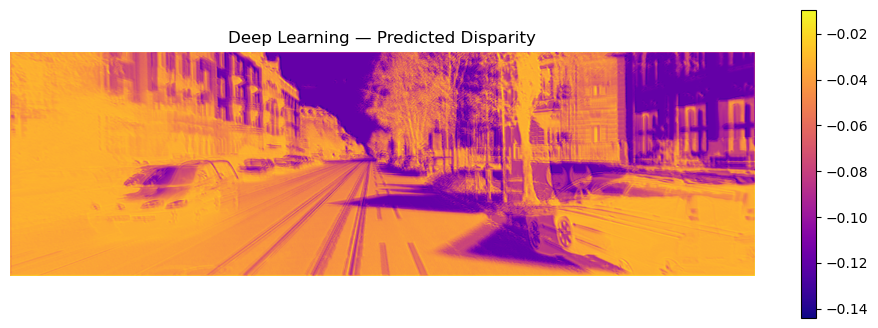

In [38]:
# ------ Predict Disparity Using CNN ----------
model.eval()
with torch.no_grad():
    L, R, GT = dataset[0]
    pred_disp = model(L.unsqueeze(0), R.unsqueeze(0)).squeeze(0).numpy()

plt.figure(figsize=(12,4))
plt.imshow(pred_disp, cmap="plasma")
plt.title("Deep Learning — Predicted Disparity")
plt.axis("off"); plt.colorbar(); plt.show()

In [39]:
# ------ CNN Evaluation ----------
gt = load_gt(0)
rmse_cnn, mae_cnn, bad_cnn = evaluate(pred_disp, gt)

print("===== CNN Evaluation =====")
print("RMSE:", rmse_cnn)
print("MAE :", mae_cnn)
print("Bad Pixels (>3px):", bad_cnn, "%")

===== CNN Evaluation =====
RMSE: 36.825387042899834
MAE : 33.95478057861328
Bad Pixels (>3px): 100.0 %
